# Linear diffusion exercise with Landlab 
[click here to websit](https://landlab.readthedocs.io/en/latest/teaching/geomorphology_exercises/hillslope_notebooks/hillslope_diffusion_class_notebook.html)



In [ ]:

# below is to make plots show up in the notebook
%matplotlib inline
# Code Block 1

import numpy as np
from matplotlib.pyplot import figure, legend, plot, title, xlabel, ylabel, ylim

from landlab.plot.imshow import imshow_grid

# Code Block 2

# setup grid
from landlab import RasterModelGrid

mg = RasterModelGrid((41, 5), 5.0)
z_vals = mg.add_zeros("topographic__elevation", at="node")

# initialize some values for plotting
ycoord_rast = mg.node_vector_to_raster(mg.node_y)
ys_grid = ycoord_rast[:, 2]

# set boundary condition.
mg.set_closed_boundaries_at_grid_edges(True, False, True, False)

# Code Block 3

from landlab.components import LinearDiffuser

D = 0.1  # initial value of 0.01 m^2/yr
lin_diffuse = LinearDiffuser(mg, linear_diffusivity=D)

# Code Block 4

# Uniform rate of rock uplift
uplift_rate = 0.0001  # meters/year, originally set to 0.0001

# Total time in years that the model will run for.
runtime = 1000000  # years, originally set to 1,000,000

# Stability criteria for timestep dt.  Coefficient can be changed
# depending on our tolerance for stability vs tolerance for run time.
dt = 0.5 * mg.dx * mg.dx / D

# nt is number of time steps
nt = int(runtime // dt)
print (nt)

# Below is to keep track of time for labeling plots
time_counter = 0

# length of uplift over a single time step, meters
uplift_per_step = uplift_rate * dt

# Code Block 5

ys = np.arange(mg.number_of_node_rows * mg.dx - mg.dx)

# location of divide or ridge crest -> middle of grid
# based on boundary conds.
divide_loc = (mg.number_of_node_rows * mg.dx - mg.dx) / 2

# half-width of the ridge
half_width = (mg.number_of_node_rows * mg.dx - mg.dx) / 2

# analytical solution for elevation under linear diffusion at steady state
zs = (uplift_rate / (2 * D)) * (np.power(half_width, 2) - np.power(ys - divide_loc, 2))


4


Text(0.5, 1.0, 'initial topographic cross section')

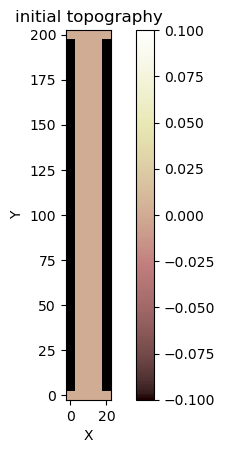

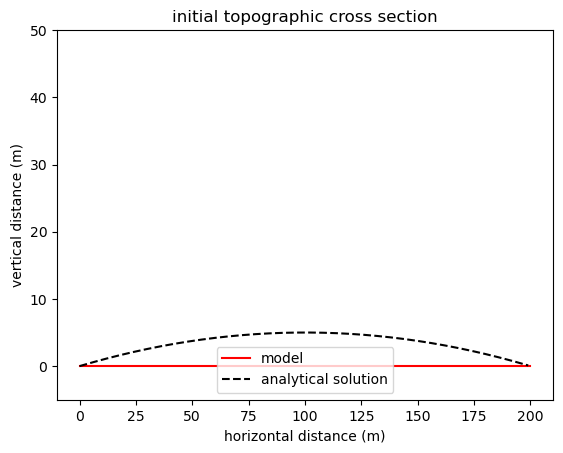

In [11]:
# Code Block 6

figure(1)
imshow_grid(mg, "topographic__elevation")
title("initial topography")
figure(2)
elev_rast = mg.node_vector_to_raster(mg.at_node["topographic__elevation"])
plot(ys_grid, elev_rast[:, 2], "r-", label="model")
plot(ys, zs, "k--", label="analytical solution")
ylim((-5, 50))  # may want to change upper limit if D changes
xlabel("horizontal distance (m)")
ylabel("vertical distance (m)")
legend(loc="lower center")
title("initial topographic cross section")

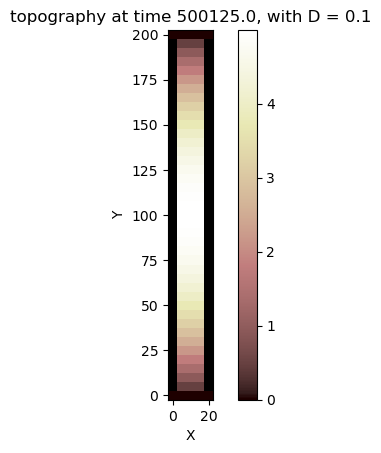

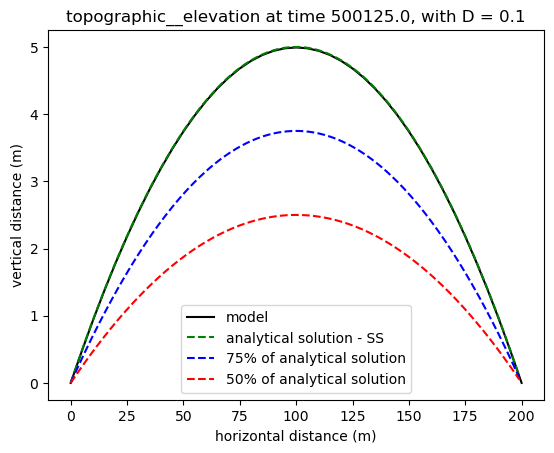

In [12]:
# Code Block 7

for i in range(nt):
    mg["node"]["topographic__elevation"][mg.core_nodes] += uplift_per_step
    lin_diffuse.run_one_step(dt)
    time_counter += dt

    # All landscape evolution is the first two lines of loop.
    # Below is simply for plotting the topography halfway through the run
    if i == int(nt // 2):
        figure(1)
        imshow_grid(mg, "topographic__elevation")
        title(f"topography at time {time_counter}, with D = {D}")
        figure(2)
        elev_rast = mg.node_vector_to_raster(mg.at_node["topographic__elevation"])
        plot(ys_grid, elev_rast[:, 2], "k-", label="model")
        plot(ys, zs, "g--", label="analytical solution - SS")
        plot(ys, zs * 0.75, "b--", label="75% of analytical solution")
        plot(ys, zs * 0.5, "r--", label="50% of analytical solution")
        xlabel("horizontal distance (m)")
        ylabel("vertical distance (m)")
        legend(loc="lower center")
        title(f"topographic__elevation at time {time_counter}, with D = {D}")

Text(0.5, 1.0, 'topographic cross section at time 1000000.0, with D = 0.1')

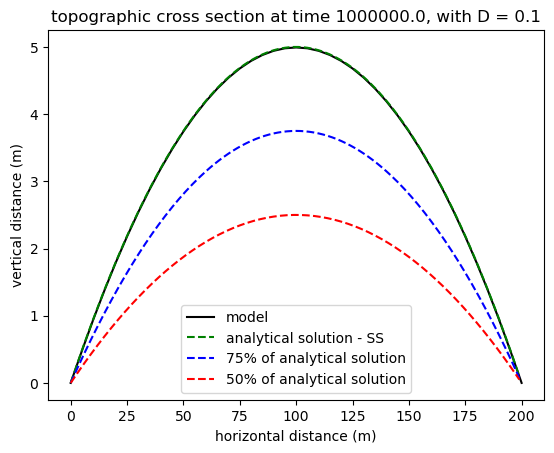

In [13]:
# Code Block 8

elev_rast = mg.node_vector_to_raster(mg.at_node["topographic__elevation"])
plot(ys_grid, elev_rast[:, 2], "k-", label="model")
plot(ys, zs, "g--", label="analytical solution - SS")
plot(ys, zs * 0.75, "b--", label="75% of analytical solution")
plot(ys, zs * 0.5, "r--", label="50% of analytical solution")
xlabel("horizontal distance (m)")
ylabel("vertical distance (m)")
legend(loc="lower center")
title(f"topographic cross section at time {time_counter}, with D = {D}")

/Users/biraj/software/anaconda3/envs/landlab/lib/python3.13/site-packages/landlab/graph/sort/sort.py:724: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  angle_of_spoke_at_hub = np.arctan2(dy, dx, where=spokes_at_hub != -1)


Text(0.5, 1.0, 'slope of the hillslope at time 1000000.0, with D = 0.01')

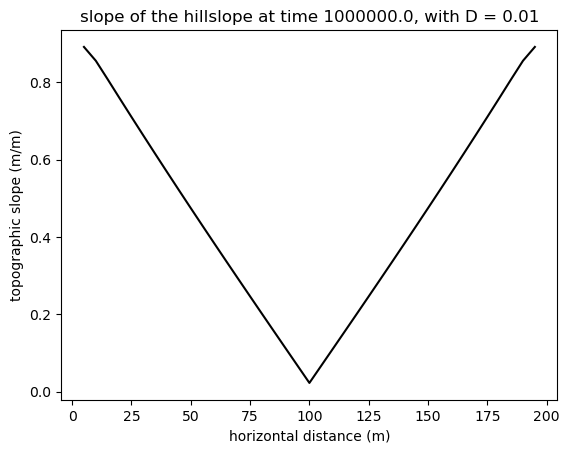

In [9]:
# Code Block 9

from landlab.components import FlowAccumulator

fr = FlowAccumulator(mg)  # intializing flow routing
fr.run_one_step()
plot(
    mg.node_y[mg.core_nodes],
    mg.at_node["topographic__steepest_slope"][mg.core_nodes],
    "k-",
)
xlabel("horizontal distance (m)")
ylabel("topographic slope (m/m)")
title(f"slope of the hillslope at time {time_counter}, with D = {D}")